In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons

In [2]:
# Features and labels
X, y = make_moons(n_samples=100, noise=0.1, random_state=42)
X[:5], y[:5]

(array([[ 1.58202308, -0.44581483],
        [ 0.0660451 ,  0.4392075 ],
        [ 0.73663111, -0.39896339],
        [-1.05692838,  0.2424558 ],
        [-0.80216162,  0.20271838]]),
 array([1, 1, 1, 0, 0]))

In [3]:
from sklearn.linear_model import LogisticRegression
# Train logistic regression
lr = LogisticRegression(random_state=42)
lr.fit(X, y)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [9]:
from sklearn.metrics import accuracy_score
# Get predictions and accuracy
y_pred = lr.predict(X)
lr_accuracy = accuracy_score(y, y_pred)
lr_accuracy

0.87

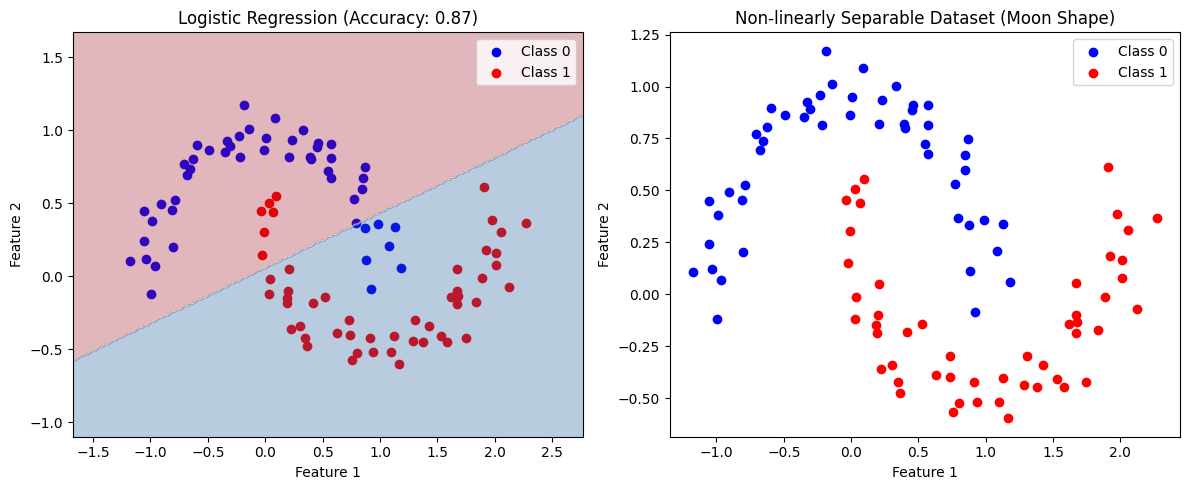

In [11]:
# Plot the results
plt.figure(figsize=(12, 5))

# Plot 1: Data points with logistic regression decision boundary
plt.subplot(1, 2, 1)
plt.scatter(X[y==0, 0], X[y==0, 1], c='blue', label='Class 0')
plt.scatter(X[y==1, 0], X[y==1, 1], c='red', label='Class 1')
# Plot decision boundary
x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200), np.linspace(y_min, y_max, 200))
Z = lr.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
plt.contourf(xx, yy, Z, alpha=0.3, cmap='RdBu')
plt.title(f'Logistic Regression (Accuracy: {lr_accuracy:.2f})')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()

# Plot 2: Actual data distribution
plt.subplot(1, 2, 2)
plt.scatter(X[y==0, 0], X[y==0, 1], c='blue', label='Class 0')
plt.scatter(X[y==1, 0], X[y==1, 1], c='red', label='Class 1')
plt.title('Non-linearly Separable Dataset (Moon Shape)')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()

plt.tight_layout()
plt.show()

In [8]:
print(f"Logistic Regression Accuracy: {lr_accuracy:.2f}")
print("\nAs you can see, logistic regression creates a linear decision boundary,")
print("which cannot adequately separate the moon-shaped dataset.")
print("A neural network with non-linear activation functions would perform much better!")

Logistic Regression Accuracy: 0.87

As you can see, logistic regression creates a linear decision boundary,
which cannot adequately separate the moon-shaped dataset.
A neural network with non-linear activation functions would perform much better!


In [13]:
from sklearn.neural_network import MLPClassifier
# Train neural network with hidden layers
nn = MLPClassifier(hidden_layer_sizes=(100, 50), activation='relu', random_state=42, max_iter=1000)
nn.fit(X, y)

,hidden_layer_sizes,"(100, ...)"
,activation,'relu'
,solver,'adam'
,alpha,0.0001
,batch_size,'auto'
,learning_rate,'constant'
,learning_rate_init,0.001
,power_t,0.5
,max_iter,1000
,shuffle,True
,random_state,42


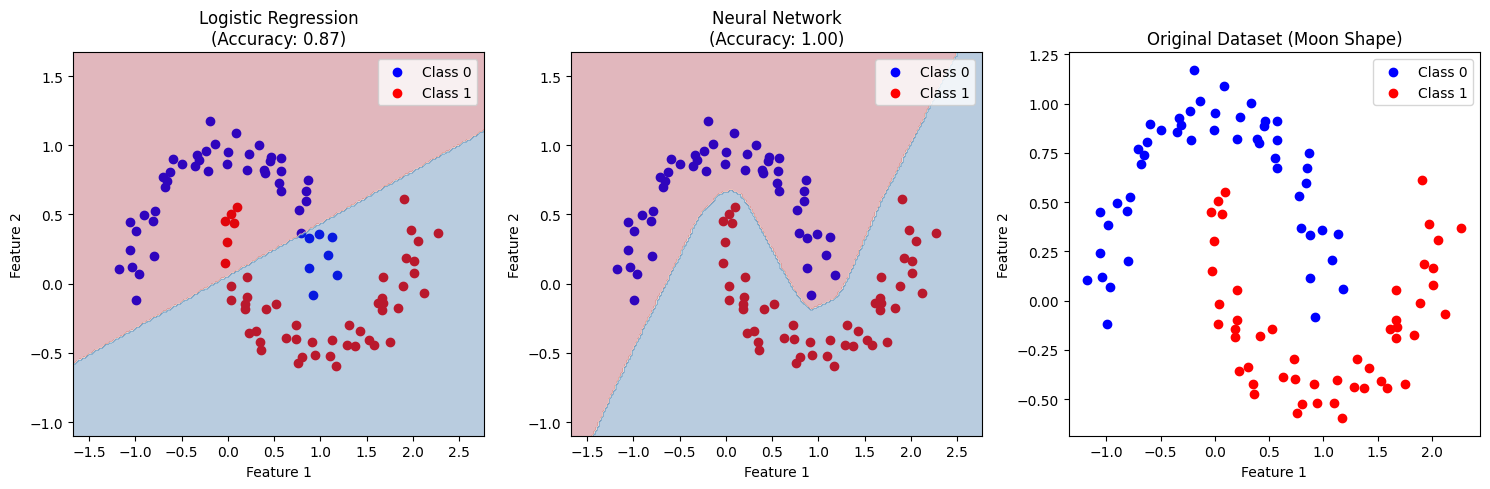

Logistic Regression Accuracy: 0.87
Neural Network Accuracy: 1.00
Improvement: 0.13


In [14]:
# Get predictions and accuracy
y_pred_nn = nn.predict(X)
nn_accuracy = accuracy_score(y, y_pred_nn)

# Plot the results
plt.figure(figsize=(15, 5))

# Plot 1: Logistic Regression decision boundary
plt.subplot(1, 3, 1)
plt.scatter(X[y==0, 0], X[y==0, 1], c='blue', label='Class 0')
plt.scatter(X[y==1, 0], X[y==1, 1], c='red', label='Class 1')
Z_lr = lr.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
plt.contourf(xx, yy, Z_lr, alpha=0.3, cmap='RdBu')
plt.title(f'Logistic Regression\n(Accuracy: {lr_accuracy:.2f})')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()

# Plot 2: Neural Network decision boundary
plt.subplot(1, 3, 2)
plt.scatter(X[y==0, 0], X[y==0, 1], c='blue', label='Class 0')
plt.scatter(X[y==1, 0], X[y==1, 1], c='red', label='Class 1')
Z_nn = nn.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
plt.contourf(xx, yy, Z_nn, alpha=0.3, cmap='RdBu')
plt.title(f'Neural Network\n(Accuracy: {nn_accuracy:.2f})')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()

# Plot 3: Original dataset
plt.subplot(1, 3, 3)
plt.scatter(X[y==0, 0], X[y==0, 1], c='blue', label='Class 0')
plt.scatter(X[y==1, 0], X[y==1, 1], c='red', label='Class 1')
plt.title('Original Dataset (Moon Shape)')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()

plt.tight_layout()
plt.show()

print(f"Logistic Regression Accuracy: {lr_accuracy:.2f}")
print(f"Neural Network Accuracy: {nn_accuracy:.2f}")
print(f"Improvement: {(nn_accuracy - lr_accuracy):.2f}")